# CSE 144 Final Project — Transfer Learning with ResNet-152

Fine-tunes a torchvision **ResNet-152** (ImageNet pretrained) on the 100-class course
dataset, then produces a Kaggle `submission.csv`.

**Pipeline:** load pretrained weights → freeze backbone → replace the classifier head
→ train the head (optionally unfreeze the last block) → evaluate on a held-out split
→ predict on the test set.

### Critical correctness notes
- **Label ordering.** Class folders are named `"0"`…`"99"`. `ImageFolder` sorts folder
  names *lexicographically* (`"0","1","10","11",...`), which would map class `"10"` to
  label 2 and scramble every prediction. The PDF warns this yields *no better than random
  guessing*. We force a **numeric** class ordering so folder `"k"` ↔ label `k`.
- **Submission set.** `test/` contains 1036 `.jpg` files, but `sample_submission.csv` lists
  exactly **1000** IDs. We iterate over the submission IDs (not `os.listdir`) so the output
  matches Kaggle's expected rows.
- **Small data.** ~1079 training images across 100 classes (as few as 4 per class). We
  freeze most of the network and rely on augmentation + a fixed seed for reproducibility.

### GPU notes (this build)
- The notebook **auto-selects CUDA** when available and falls back to CPU otherwise. Training
  on GPU is ~10–50× faster than CPU for these models.
- Uses **automatic mixed precision (AMP)** on CUDA to roughly halve VRAM use and speed up
  matmuls — important on a 4 GB card (e.g. GTX 960).
- `BATCH_SIZE` defaults are tuned to fit a 4 GB GPU. Raise them on larger cards; lower them
  if you hit out-of-memory errors.
- **Requires a CUDA build of PyTorch.** If `torch.cuda.is_available()` prints `False`, install
  one matching your driver, e.g. `pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126`.

## 1. Imports, seeding, and configuration

In [1]:
import os
import csv
import random
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet152, ResNet152_Weights
from PIL import Image

# ----------------------------- Reproducibility -----------------------------
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# ----------------------------- Paths ----------------------------------------
DATA_ROOT  = Path("ucsc-cse-144-spring-2026-final-project")
TRAIN_DIR  = DATA_ROOT / "train"
TEST_DIR   = DATA_ROOT / "test"
SAMPLE_SUB = DATA_ROOT / "sample_submission.csv"
SUBMISSION = "submission_resnet.csv"
CKPT_PATH  = "resnet152_finetuned.pth"

# ----------------------------- Device ---------------------------------------
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_CUDA = DEVICE.type == "cuda"
USE_AMP  = USE_CUDA          # mixed precision only helps/works on CUDA
if USE_CUDA:
    # Auto-tune conv algorithms for the fixed 224x224 input size -> faster.
    torch.backends.cudnn.benchmark = True

# ----------------------------- Hyperparameters ------------------------------
NUM_CLASSES   = 100
IMG_SIZE      = 224
VAL_FRAC      = 0.2          # fraction of train images held out for validation
# Full fine-tune of ResNet-152 with AMP peaks ~3.0 GB at batch 16 -> fits a 4 GB GPU.
# Drop to 8 if you hit OOM (close other GPU apps first).
BATCH_SIZE    = 16 if USE_CUDA else 8
# NUM_WORKERS=0: multiprocessing DataLoader workers are unreliable on Windows (they
# re-import the notebook and can crash/hang). The dataset is tiny (~1k imgs), so
# single-process loading is plenty fast and avoids that failure mode.
NUM_WORKERS   = 0
EPOCHS        = 30          # full fine-tune needs more epochs than head-only

# FINE_TUNE_MODE controls how much of the backbone is trainable:
#   "full"   -> unfreeze the entire network (best accuracy on this dataset)
#   "layer4" -> unfreeze only the last residual block + head
#   "head"   -> freeze backbone, train only the new linear head (fast, low accuracy)
FINE_TUNE_MODE = "full"

LR_HEAD       = 1e-3        # learning rate for the new classifier head
LR_BACKBONE   = 1e-4        # smaller LR for pretrained backbone layers
WEIGHT_DECAY  = 1e-4
# Reduced from 0.1: MixUp/CutMix (below) are now the primary label-softening
# regularizer, so we keep only a little smoothing to avoid over-softening targets.
LABEL_SMOOTHING = 0.05

print(f"Device: {DEVICE}")
print(f"Torch {torch.__version__}, CUDA available: {torch.cuda.is_available()}")
print(f"Fine-tune mode: {FINE_TUNE_MODE} | epochs: {EPOCHS}")
if USE_CUDA:
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name}, {props.total_memory/1e9:.1f} GB VRAM | AMP: {USE_AMP} | batch {BATCH_SIZE}")
else:
    print("Running on CPU — this will be slow. Install a CUDA build of torch to use the GPU.")

Device: cuda
Torch 2.12.0+cu126, CUDA available: True
Fine-tune mode: full | epochs: 30
GPU: NVIDIA GeForce GTX 960, 4.3 GB VRAM | AMP: True | batch 16


## 2. Data: numeric class ordering, transforms, and train/val split

We build the dataset twice over the same files so train and validation can use different
transforms (augmentation only on train). Both share **one numeric class mapping** so the
label of folder `"k"` is exactly `k`.

In [2]:
# ImageNet normalization (matches the pretrained weights' expected preprocessing)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ----------------------- Augmentation switches -----------------------
# These regularize a model that otherwise overfits ~860 training images
# (train acc hit 100% by epoch 7 in the head-only/plain-aug baseline).
USE_ROTATION   = True    # add RandomRotation to the train transforms
ROTATION_DEG   = 20      # +/- degrees; corners are cropped away by RandomResizedCrop

# MixUp / CutMix operate on BATCHES inside the training loop (not here) and produce
# soft labels. They are configured here but applied in the train-loop cell.
USE_MIXUP_CUTMIX = True   # randomly apply MixUp or CutMix to each training batch
MIX_PROB         = 0.5    # probability a given batch is mixed at all
MIX_ALPHA        = 0.2    # Beta(alpha, alpha) — smaller alpha = milder mixing

# Build the train transform list, inserting rotation before the random crop so the
# crop hides the rotated black corners.
_train_ops = []
if USE_ROTATION:
    _train_ops.append(transforms.RandomRotation(ROTATION_DEG))
_train_ops += [
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
]
train_tfms = transforms.Compose(_train_ops)

eval_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
print(f"Rotation: {USE_ROTATION} (+/-{ROTATION_DEG} deg) | "
      f"MixUp/CutMix: {USE_MIXUP_CUTMIX} (p={MIX_PROB}, alpha={MIX_ALPHA})")

# --- Force class folders to be ordered NUMERICALLY (0,1,2,...) not lexically ---
class_names = sorted(os.listdir(TRAIN_DIR), key=int)        # ["0","1",...,"99"]
class_to_idx = {name: int(name) for name in class_names}    # folder "k" -> label k

def make_dataset(tfms):
    ds = ImageFolder(str(TRAIN_DIR), transform=tfms)
    # Override ImageFolder's lexicographic mapping with our numeric one and
    # remap every sample's target so it stays consistent.
    old_idx_to_class = {v: k for k, v in ds.class_to_idx.items()}
    ds.samples = [(p, class_to_idx[old_idx_to_class[t]]) for p, t in ds.samples]
    ds.targets = [t for _, t in ds.samples]
    ds.imgs = ds.samples
    ds.class_to_idx = class_to_idx
    ds.classes = class_names
    return ds

# Sanity check: a file in folder "10" must now carry label 10.
_check = make_dataset(eval_tfms)
_ex = next(p for p, _ in _check.samples if os.path.sep + "10" + os.path.sep in p)
_lbl = dict(_check.samples)[_ex]
print(f"Example from folder '10' -> label {_lbl}  (expected 10)")
assert _lbl == 10, "Label ordering is wrong!"
print(f"Total training images: {len(_check)}  across {len(class_names)} classes")

Rotation: True (+/-20 deg) | MixUp/CutMix: True (p=0.5, alpha=0.2)
Example from folder '10' -> label 10  (expected 10)
Total training images: 1079  across 100 classes


In [3]:
# Train/val split by index (same split applied to both transform variants)
set_seed(SEED)
n = len(_check)
indices = list(range(n))
random.Random(SEED).shuffle(indices)
val_size = int(round(VAL_FRAC * n))
val_idx, train_idx = indices[:val_size], indices[val_size:]

train_ds_full = make_dataset(train_tfms)
val_ds_full   = make_dataset(eval_tfms)
train_ds = Subset(train_ds_full, train_idx)
val_ds   = Subset(val_ds_full,   val_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"))
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"))

print(f"Train: {len(train_ds)} imgs | Val: {len(val_ds)} imgs")

Train: 863 imgs | Val: 216 imgs


## 3. Model: load pretrained ResNet-152, freeze backbone, replace head

In [4]:
def build_model(mode: str = FINE_TUNE_MODE):
    model = resnet152(weights=ResNet152_Weights.IMAGENET1K_V2)

    if mode == "full":
        # Train every layer (head + entire backbone).
        for p in model.parameters():
            p.requires_grad = True
    elif mode == "layer4":
        # Freeze everything, then unfreeze only the last residual block.
        for p in model.parameters():
            p.requires_grad = False
        for p in model.layer4.parameters():
            p.requires_grad = True
    elif mode == "head":
        # Freeze the whole backbone; only the new head trains.
        for p in model.parameters():
            p.requires_grad = False
    else:
        raise ValueError(f"Unknown FINE_TUNE_MODE: {mode!r}")

    # Replace the 1000-way ImageNet head with a 100-way head (always trainable).
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, NUM_CLASSES)  # newly created -> requires_grad=True

    return model.to(DEVICE)

model = build_model()
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total     = sum(p.numel() for p in model.parameters())
print(f"Mode '{FINE_TUNE_MODE}': trainable params {n_trainable:,} / {n_total:,} "
      f"({100*n_trainable/n_total:.1f}%)")

Mode 'full': trainable params 58,348,708 / 58,348,708 (100.0%)


In [5]:
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

# Two param groups: higher LR for the fresh head, lower for any unfrozen backbone layers.
head_params     = list(model.fc.parameters())
backbone_params = [p for nm, p in model.named_parameters()
                   if p.requires_grad and not nm.startswith("fc.")]
param_groups = [{"params": head_params, "lr": LR_HEAD}]
if backbone_params:
    param_groups.append({"params": backbone_params, "lr": LR_BACKBONE})
print(f"Optimizing {len(head_params)} head tensors + {len(backbone_params)} backbone tensors")

optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# GradScaler rescales gradients so fp16 mixed-precision training stays numerically stable.
# It is a no-op (enabled=False) on CPU.
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

Optimizing 2 head tensors + 465 backbone tensors


## 4. Train / evaluate loops

In [6]:
# --------------------------- MixUp / CutMix ---------------------------
# Both blend two training examples and produce a SOFT target (a mix of two
# one-hot labels). MixUp blends whole images; CutMix pastes a rectangular patch
# of one image onto another. We pick one at random per batch.

def _rand_bbox(h, w, lam):
    """Random box whose area is (1 - lam) of the image (for CutMix)."""
    cut_rat = np.sqrt(1.0 - lam)
    cw, ch = int(w * cut_rat), int(h * cut_rat)
    cx, cy = np.random.randint(w), np.random.randint(h)
    x1, x2 = np.clip(cx - cw // 2, 0, w), np.clip(cx + cw // 2, 0, w)
    y1, y2 = np.clip(cy - ch // 2, 0, h), np.clip(cy + ch // 2, 0, h)
    return x1, y1, x2, y2

def mix_batch(imgs, labels):
    """Return (mixed_imgs, labels_a, labels_b, lam).

    With prob (1 - MIX_PROB) returns the batch unchanged (lam=1). Otherwise
    applies MixUp or CutMix (50/50) using a shuffled copy of the batch as the
    second example. The soft target is lam*one_hot(labels_a) + (1-lam)*one_hot(labels_b).
    """
    if (not USE_MIXUP_CUTMIX) or (np.random.rand() > MIX_PROB):
        return imgs, labels, labels, 1.0

    lam = float(np.random.beta(MIX_ALPHA, MIX_ALPHA))
    perm = torch.randperm(imgs.size(0), device=imgs.device)
    labels_b = labels[perm]

    if np.random.rand() < 0.5:                      # ---- MixUp ----
        imgs = lam * imgs + (1.0 - lam) * imgs[perm]
    else:                                           # ---- CutMix ----
        h, w = imgs.shape[2], imgs.shape[3]
        x1, y1, x2, y2 = _rand_bbox(h, w, lam)
        imgs[:, :, y1:y2, x1:x2] = imgs[perm, :, y1:y2, x1:x2]
        # Adjust lam to the EXACT pasted-area fraction.
        lam = 1.0 - ((x2 - x1) * (y2 - y1) / (h * w))
    return imgs, labels, labels_b, lam

def soft_ce(logits, labels_a, labels_b, lam):
    """label-smoothed cross-entropy under a two-target (MixUp/CutMix) blend."""
    return (lam * criterion(logits, labels_a)
            + (1.0 - lam) * criterion(logits, labels_b))


def run_epoch(loader, train: bool):
    model.train(train)
    total, correct, loss_sum = 0, 0, 0.0
    torch.set_grad_enabled(train)
    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        if train:
            optimizer.zero_grad(set_to_none=True)
            # Mix the batch (no-op when disabled / not selected this batch).
            mixed, lab_a, lab_b, lam = mix_batch(imgs, labels)
            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                out = model(mixed)
                loss = soft_ce(out, lab_a, lab_b, lam)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            # Report training accuracy against the dominant (lam-weighted) label
            # purely for monitoring; the gradient used the soft target above.
            ref = lab_a if lam >= 0.5 else lab_b
            correct += (out.argmax(1) == ref).sum().item()
        else:
            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                out = model(imgs)
                loss = criterion(out, labels)   # plain CE on real labels
            correct += (out.argmax(1) == labels).sum().item()
        loss_sum += loss.item() * imgs.size(0)
        total    += imgs.size(0)
    torch.set_grad_enabled(True)
    return loss_sum / total, correct / total

best_val_acc = 0.0
history = []
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)
    scheduler.step()
    history.append((tr_loss, tr_acc, va_loss, va_acc))
    flag = ""
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save({"model_state": model.state_dict(),
                    "class_names": class_names,
                    "val_acc": va_acc}, CKPT_PATH)
        flag = "  <- saved best"
    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"train loss {tr_loss:.3f} acc {tr_acc:.3f} | "
          f"val loss {va_loss:.3f} acc {va_acc:.3f} | "
          f"{time.time()-t0:5.1f}s{flag}")

print(f"\nBest val accuracy: {best_val_acc:.3f}")

Epoch  1/30 | train loss 4.082 acc 0.123 | val loss 3.006 acc 0.278 |  82.7s  <- saved best
Epoch  2/30 | train loss 2.333 acc 0.497 | val loss 2.104 acc 0.477 |  56.2s  <- saved best
Epoch  3/30 | train loss 1.776 acc 0.673 | val loss 1.784 acc 0.519 |  56.9s  <- saved best
Epoch  4/30 | train loss 1.213 acc 0.854 | val loss 1.644 acc 0.606 |  56.9s  <- saved best
Epoch  5/30 | train loss 1.184 acc 0.882 | val loss 1.731 acc 0.574 |  56.4s
Epoch  6/30 | train loss 0.964 acc 0.929 | val loss 1.670 acc 0.620 |  56.8s  <- saved best
Epoch  7/30 | train loss 0.927 acc 0.947 | val loss 1.669 acc 0.620 |  56.5s
Epoch  8/30 | train loss 0.699 acc 0.962 | val loss 1.636 acc 0.620 |  56.4s
Epoch  9/30 | train loss 0.884 acc 0.939 | val loss 1.700 acc 0.625 |  57.0s  <- saved best
Epoch 10/30 | train loss 0.817 acc 0.935 | val loss 1.617 acc 0.620 |  56.3s
Epoch 11/30 | train loss 0.786 acc 0.952 | val loss 1.692 acc 0.597 |  56.5s
Epoch 12/30 | train loss 0.812 acc 0.959 | val loss 1.672 acc 0

## 4b. Training curves (for the report)

Plots the per-epoch **loss** and **accuracy** for the training and validation splits, marks
the 60% Kaggle baseline, and annotates the best validation epoch (the checkpoint we keep).
The figure is saved to `resnet_training_curves.png` for inclusion in the report.

> Run this *after* the training cell above. It reads the `history` list, so it works with a
> full 30-epoch run or a partial one (e.g. if training was interrupted).

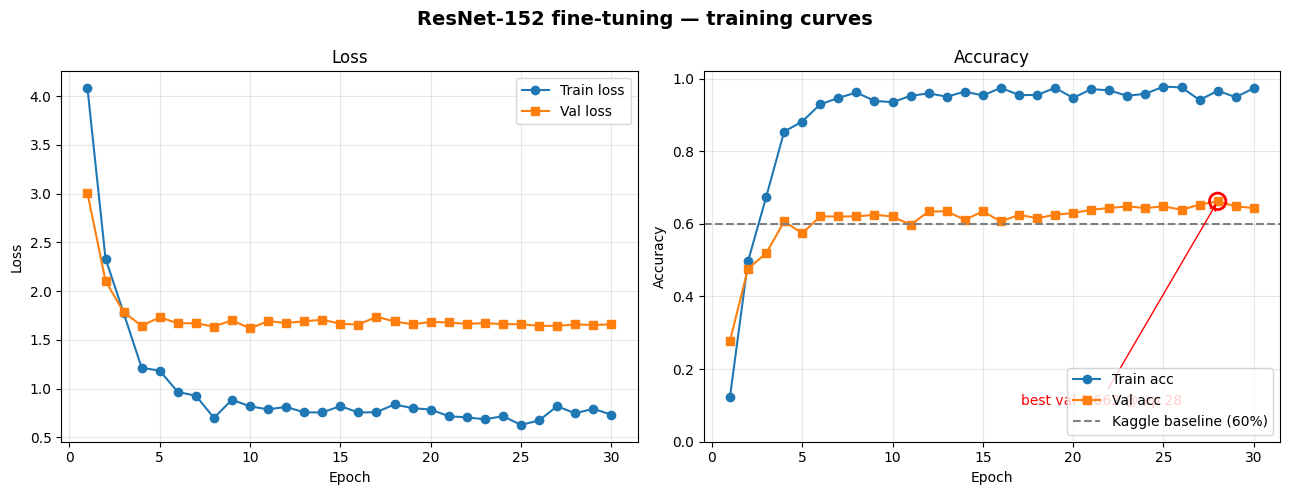

Saved resnet_training_curves.png
Best val accuracy 0.662 at epoch 28 (30 epochs recorded)


In [7]:
import matplotlib.pyplot as plt

CURVES_PNG = "resnet_training_curves.png"
BASELINE_ACC = 0.60  # Kaggle baseline to pass

if not history:
    print("No training history yet — run the training cell above first.")
else:
    # history rows are (train_loss, train_acc, val_loss, val_acc)
    hist = np.array(history, dtype=float)
    epochs = np.arange(1, len(hist) + 1)
    tr_loss, tr_acc, va_loss, va_acc = hist[:, 0], hist[:, 1], hist[:, 2], hist[:, 3]
    best_ep = int(np.argmax(va_acc)) + 1
    best_va = va_acc[best_ep - 1]

    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("ResNet-152 fine-tuning — training curves", fontsize=14, fontweight="bold")

    # --- Loss ---
    ax_loss.plot(epochs, tr_loss, "o-", label="Train loss", color="tab:blue")
    ax_loss.plot(epochs, va_loss, "s-", label="Val loss", color="tab:orange")
    ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss")
    ax_loss.set_title("Loss"); ax_loss.grid(True, alpha=0.3); ax_loss.legend()

    # --- Accuracy ---
    ax_acc.plot(epochs, tr_acc, "o-", label="Train acc", color="tab:blue")
    ax_acc.plot(epochs, va_acc, "s-", label="Val acc", color="tab:orange")
    ax_acc.axhline(BASELINE_ACC, ls="--", color="gray",
                   label=f"Kaggle baseline ({BASELINE_ACC:.0%})")
    # Mark the best validation epoch (the checkpoint we keep).
    ax_acc.scatter([best_ep], [best_va], s=140, facecolors="none",
                   edgecolors="red", linewidths=2, zorder=5)
    ax_acc.annotate(f"best val {best_va:.3f} @ ep {best_ep}",
                    xy=(best_ep, best_va), xytext=(0.55, 0.1),
                    textcoords="axes fraction",
                    arrowprops=dict(arrowstyle="->", color="red"), color="red")
    ax_acc.set_xlabel("Epoch"); ax_acc.set_ylabel("Accuracy")
    ax_acc.set_ylim(0, 1.02); ax_acc.set_title("Accuracy")
    ax_acc.grid(True, alpha=0.3); ax_acc.legend(loc="lower right")

    fig.tight_layout()
    fig.savefig(CURVES_PNG, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {CURVES_PNG}")
    print(f"Best val accuracy {best_va:.3f} at epoch {best_ep} "
          f"({len(hist)} epochs recorded)")

## 5. Inference on the test set → `submission_resnet.csv`

Predicts **every image in `test/`** (all 1036 files, IDs `0.jpg`…`1035.jpg`), sorted
numerically, and loads the best checkpoint saved above.

> **Note on submission length.** `sample_submission.csv` lists only the 1000 IDs Kaggle
> actually scores (`0`–`999`). The 36 extra files (`1000`–`1035`) are present in `test/` but
> are *not* on the leaderboard. We write all 1036 rows for completeness; the cell also reports
> whether the 1000 scored IDs are all covered. If a grader requires *exactly* the template's
> 1000 rows, set `PREDICT_ALL = False`.

In [8]:
# Reload best checkpoint
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Loaded checkpoint with val acc {ckpt['val_acc']:.3f}")

# Set of IDs Kaggle actually scores (from the template), used only for a coverage check.
with open(SAMPLE_SUB, newline="") as f:
    reader = csv.reader(f)
    next(reader)
    scored_ids = {row[0] for row in reader}

PREDICT_ALL = True  # True -> all 1036 test files; False -> only the 1000 template IDs

if PREDICT_ALL:
    # Every .jpg in test/, sorted by numeric ID (0.jpg, 1.jpg, ..., 1035.jpg).
    test_ids = sorted((p.name for p in TEST_DIR.glob("*.jpg")),
                      key=lambda s: int(s.split(".")[0]))
else:
    test_ids = sorted(scored_ids, key=lambda s: int(s.split(".")[0]))
print(f"Predicting {len(test_ids)} images (PREDICT_ALL={PREDICT_ALL})")

@torch.no_grad()
def predict_image(path):
    img = Image.open(path).convert("RGB")
    x = eval_tfms(img).unsqueeze(0).to(DEVICE)
    with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
        out = model(x)
    return int(out.argmax(1).item())

rows = []
t0 = time.time()
for i, img_id in enumerate(test_ids):
    pred = predict_image(TEST_DIR / img_id)
    rows.append((img_id, pred))
    if (i + 1) % 200 == 0:
        print(f"  {i+1}/{len(test_ids)} predicted ({time.time()-t0:.1f}s)")

with open(SUBMISSION, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["ID", "Label"])
    w.writerows(rows)

# Coverage check: confirm every scored ID got a prediction.
predicted_ids = {r[0] for r in rows}
missing = scored_ids - predicted_ids
print(f"\nWrote {len(rows)} predictions to {SUBMISSION}")
print(f"Scored IDs covered: {len(scored_ids - missing)}/{len(scored_ids)}"
      + (f"  MISSING {len(missing)}: {sorted(missing)[:5]}..." if missing else "  (all present)"))
print("First 5 rows:", rows[:5])

Loaded checkpoint with val acc 0.662
Predicting 1036 images (PREDICT_ALL=True)
  200/1036 predicted (9.8s)
  400/1036 predicted (19.0s)
  600/1036 predicted (34.8s)
  800/1036 predicted (48.1s)
  1000/1036 predicted (58.3s)

Wrote 1036 predictions to submission_resnet.csv
Scored IDs covered: 1000/1000  (all present)
First 5 rows: [('0.jpg', 62), ('1.jpg', 43), ('2.jpg', 38), ('3.jpg', 62), ('4.jpg', 42)]
